# Counterparty Risk Simulator — Walkthrough

This notebook builds a small collateralized netting set, runs the Monte Carlo
engine, and reads the exposure and CVA metrics off the simulated distribution.

**Pipeline:** correlated Hull–White (rates) + GBM (equity) → analytic reprice of
swaps & options along every path → net + collateralize → EE / PFE / CVA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ccr.config import MarketConfig, ScenarioConfig, SimConfig
from ccr.engine import CSA, Uncollateralized, run, run_detailed
from ccr.instruments import InterestRateSwap, EuropeanEquityOption
from ccr.metrics import HazardCurve

Matplotlib is building the font cache; this may take a moment.


## 1. Define the portfolio and market

A 5y payer swap plus a 3y equity call.

In [2]:
portfolio = [
    InterestRateSwap(10_000_000, 0.025, 0.0, 5.0, 0.5, pay_fixed=True, name='IRS 5y'),
    EuropeanEquityOption(100.0, 3.0, 0.25, is_call=True, long=True, notional=50_000, name='Call 3y'),
]
market = MarketConfig(flat_rate=0.03, hw_a=0.10, hw_sigma=0.012,
                      equity_s0=100.0, equity_sigma=0.22, rho_rate_equity=0.30,
                      basis_spread=0.0005)
sim = SimConfig(n_paths=40_000, n_steps=60, horizon=5.0, seed=1, pfe_level=0.975)
hazard = HazardCurve.from_cds_spread(spread_bps=150, recovery=0.4)

## 2. Uncollateralized exposure profile

EE peaks mid-life and rolls down — the classic swap hump, lifted by the option.

ExposureResult(EPE=765,795, MaxPFE=6,282,530, CVA=55,252, PFE@97.5%, paths=40,000)


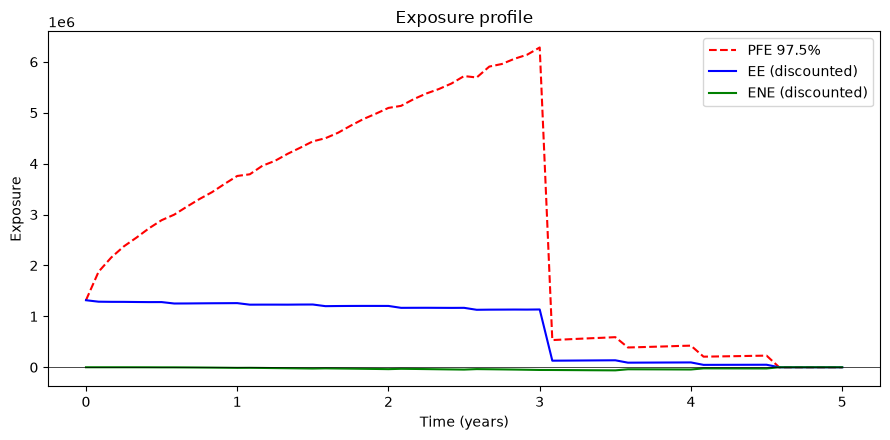

In [3]:
scn = ScenarioConfig(name='uncollateralized', portfolio=portfolio, market=market,
                     sim=sim, collateral=Uncollateralized(), hazard=hazard)
res = run(scn)
print(res)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res.times, res.pfe, 'r--', label=f'PFE {res.pfe_level:.1%}')
ax.plot(res.times, res.ee, 'b-', label='EE (discounted)')
ax.plot(res.times, res.ene, 'g-', label='ENE (discounted)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time (years)'); ax.set_ylabel('Exposure'); ax.legend(); ax.set_title('Exposure profile')
plt.tight_layout(); plt.show()

## 3. The effect of collateral (CSA)

A CSA with a 250k threshold, 50k MTA, and a 10-day margin period of risk. Collateralized exposure ≈ the adverse MtM move over the MPoR — much smaller, so CVA falls sharply.

Uncollateralized: ExposureResult(EPE=765,795, MaxPFE=6,282,530, CVA=55,252, PFE@97.5%, paths=40,000)
Collateralized  : ExposureResult(EPE=164,796, MaxPFE=1,065,473, CVA=11,843, PFE@97.5%, paths=40,000)
CVA reduction: 78.6%


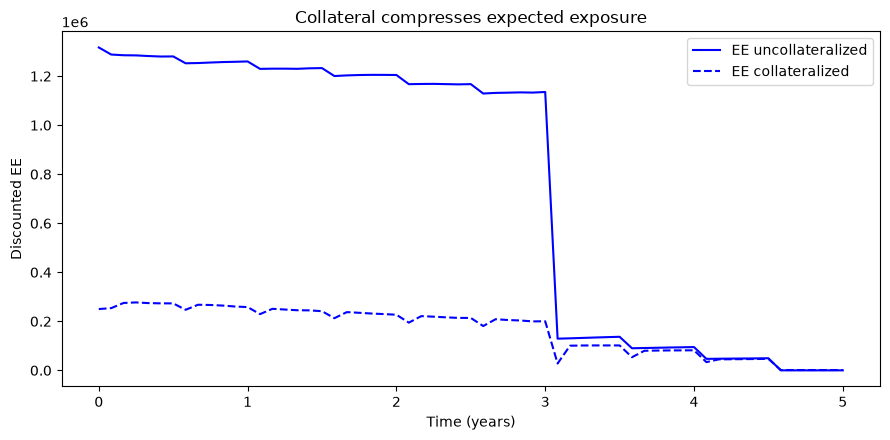

In [4]:
scn.collateral = CSA(threshold=250_000, min_transfer_amount=50_000, mpor_years=10/252)
res_col = run(scn)
print('Uncollateralized:', res)
print('Collateralized  :', res_col)
print(f'CVA reduction: {1 - res_col.cva / res.cva:.1%}')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res.times, res.ee, 'b-', label='EE uncollateralized')
ax.plot(res_col.times, res_col.ee, 'b--', label='EE collateralized')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Discounted EE'); ax.legend()
ax.set_title('Collateral compresses expected exposure')
plt.tight_layout(); plt.show()

## 4. Netting benefit

Adding an offsetting receiver swap nets down exposure — the reason netting sets exist.

In [5]:
offset = InterestRateSwap(10_000_000, 0.025, 0.0, 5.0, 0.5, pay_fixed=False, name='IRS offset')
scn_net = ScenarioConfig(name='netted', portfolio=portfolio + [offset], market=market,
                         sim=sim, collateral=Uncollateralized(), hazard=hazard)
res_net = run(scn_net)
print('Standalone EPE :', f'{res.epe:,.0f}')
print('With offset EPE:', f'{res_net.epe:,.0f}')

Standalone EPE : 765,795
With offset EPE: 621,104


## 5. Exposure distribution at a fixed horizon

The full distribution the percentiles are read from.

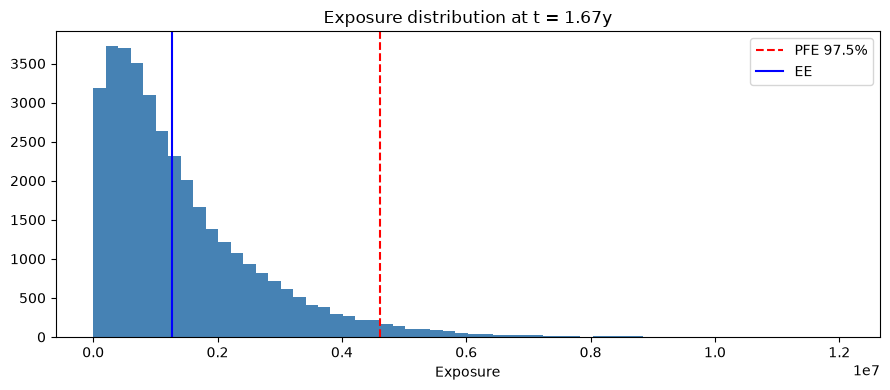

In [6]:
diag = run_detailed(ScenarioConfig(name='dist', portfolio=portfolio, market=market,
                                   sim=sim, collateral=Uncollateralized(), hazard=hazard))
k = len(diag.result.times) // 3
col = diag.exposure[:, k]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(col[col > 0], bins=60, color='steelblue')
ax.axvline(np.quantile(col, 0.975), color='r', ls='--', label='PFE 97.5%')
ax.axvline(col.mean(), color='b', ls='-', label='EE')
ax.set_title(f'Exposure distribution at t = {diag.result.times[k]:.2f}y')
ax.set_xlabel('Exposure'); ax.legend(); plt.tight_layout(); plt.show()